# 🧾 JSON Schema Validator - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/json-validator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/json-validator/demo.ipynb)

> *"API payloads keep breaking."*

A producer drops a field or flips a type, and a downstream consumer silently
corrupts data. This notebook validates payloads against a JSON Schema and returns
**every** problem at once - then infers a starter schema from a sample so you
don't have to hand-write one.

**What we cover**
1. Validate a bad payload (catch all errors)
2. Validate a good payload
3. Infer a schema from a sample
4. Batch-validate a stream of payloads
5. Visualize the failure breakdown


## Step 1 - Validate against a schema, get *all* errors

Note we surface both the missing `email` **and** the wrong-typed `id` - not just
the first failure. That's the difference between one debugging round-trip and five.


In [1]:
from __future__ import annotations

from typing import Any, Dict, List
from jsonschema import Draft7Validator

def validate_payload(schema: Dict[str, Any], data: Any) -> Dict[str, Any]:
    try:
        validator = Draft7Validator(schema)
    except Exception as exc:
        return {"valid": False, "error_count": 1, "errors": [{"path": "<schema>", "message": f"invalid schema: {exc}"}]}
    errors: List[Dict[str, str]] = []
    for err in sorted(validator.iter_errors(data), key=lambda e: list(e.path)):
        path = "$" + "".join(f"[{p!r}]" if isinstance(p, str) else f"[{p}]" for p in err.path)
        errors.append({"path": path, "message": err.message})
    return {"valid": not errors, "error_count": len(errors), "errors": errors}

schema = {
    "type": "object",
    "properties": {
        "id": {"type": "integer"},
        "email": {"type": "string"},
        "amount": {"type": "number", "minimum": 0},
    },
    "required": ["id", "email", "amount"],
}

bad = {"id": "abc", "amount": -5}
validate_payload(schema, bad)

{'valid': False,
 'error_count': 3,
 'errors': [{'path': '$', 'message': "'email' is a required property"},
  {'path': "$['amount']", 'message': '-5 is less than the minimum of 0'},
  {'path': "$['id']", 'message': "'abc' is not of type 'integer'"}]}

## Step 2 - A valid payload passes cleanly

In [2]:
good = {"id": 42, "email": "alice@example.com", "amount": 19.99}
validate_payload(schema, good)

{'valid': True, 'error_count': 0, 'errors': []}

## Step 3 - Infer a starter schema from a sample

Hand-writing schemas is tedious. Point this at one representative payload and
tighten the output by hand.


In [3]:
def _json_type(value: Any) -> str:
    if isinstance(value, bool): return "boolean"
    if isinstance(value, int): return "integer"
    if isinstance(value, float): return "number"
    if isinstance(value, str): return "string"
    if isinstance(value, list): return "array"
    if isinstance(value, dict): return "object"
    return "null"

def infer_schema(sample: Any) -> Dict[str, Any]:
    t = _json_type(sample)
    if t == "object":
        return {"type": "object",
                "properties": {k: infer_schema(v) for k, v in sample.items()},
                "required": list(sample.keys()), "additionalProperties": True}
    if t == "array":
        return {"type": "array", "items": infer_schema(sample[0])} if sample else {"type": "array"}
    return {"type": t}

import json
print(json.dumps(infer_schema({"id": 1, "email": "a@b.com", "tags": ["vip"], "active": True}), indent=2))

{
  "type": "object",
  "properties": {
    "id": {
      "type": "integer"
    },
    "email": {
      "type": "string"
    },
    "tags": {
      "type": "array",
      "items": {
        "type": "string"
      }
    },
    "active": {
      "type": "boolean"
    }
  },
  "required": [
    "id",
    "email",
    "tags",
    "active"
  ],
  "additionalProperties": true
}


## Step 4 - Batch-validate a stream

In a real pipeline you'd run every incoming record through the validator and
quarantine the failures. Here's a mixed batch.


In [4]:
batch = [
    {"id": 1, "email": "a@b.com", "amount": 10.0},     # ok
    {"id": "2", "email": "b@c.com", "amount": 5.0},     # id wrong type
    {"id": 3, "amount": 7.0},                            # missing email
    {"id": 4, "email": "d@e.com", "amount": -1.0},       # negative amount
    {"id": 5, "email": "e@f.com", "amount": 99.0},      # ok
]
results = [validate_payload(schema, p) for p in batch]
for i, r in enumerate(results):
    flag = "PASS" if r["valid"] else f"FAIL ({r['error_count']})"
    print(f"record {i}: {flag}")

record 0: PASS
record 1: FAIL (1)
record 2: FAIL (1)
record 3: FAIL (1)
record 4: PASS


## Step 5 - Failure breakdown, visualized

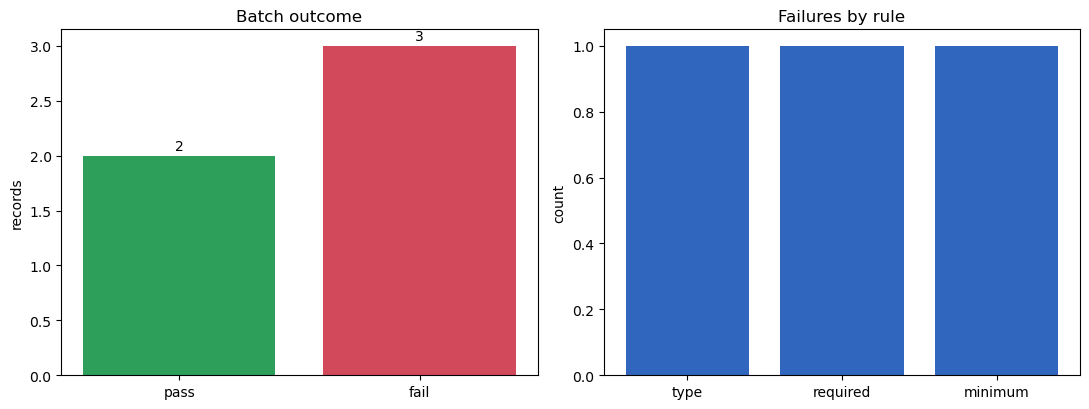

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

reasons = Counter()
for r in results:
    for e in r["errors"]:
        # bucket by the rule that failed (last word of the message is good enough here)
        key = "type" if "is not of type" in e["message"] else \
              "required" if "required property" in e["message"] else \
              "minimum" if "less than" in e["message"] or "minimum" in e["message"] else "other"
        reasons[key] += 1

passes = sum(r["valid"] for r in results)
fails = len(results) - passes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.bar(["pass", "fail"], [passes, fails], color=["#2e9e5b", "#d1495b"])
ax1.set_title("Batch outcome"); ax1.set_ylabel("records")
for i, v in enumerate([passes, fails]):
    ax1.text(i, v + 0.05, str(v), ha="center")

if reasons:
    ax2.bar(list(reasons.keys()), list(reasons.values()), color="#3066be")
ax2.set_title("Failures by rule"); ax2.set_ylabel("count")
plt.tight_layout(); plt.savefig("validation.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- Validation returns **every** error with a JSON-path, not just the first.
- A bad schema is reported, never raised - safe to expose as an API.
- `infer_schema` bootstraps a Draft-7 schema from one sample payload.

This is the engine behind the FastAPI service in `api.py`.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run the microservice:**
```bash
pip install -r requirements.txt
uvicorn api:app --reload
# open http://localhost:8000  (built-in test form)  or  /docs
```
